In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

In [3]:
X_train_scaled = pd.read_csv("../data/processed/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")

y_train_smote = pd.read_csv("../data/processed/y_train_smote.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [4]:
print(type(y_train_smote))
print(type(y_test))

<class 'pandas.Series'>
<class 'pandas.Series'>


In [5]:
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train_smote)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [6]:
y_pred = log_reg.predict(X_test_scaled)

y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

In [7]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8117
Precision: 0.2286
Recall   : 0.2618
F1 Score : 0.2441


In [8]:
cm = confusion_matrix(y_test, y_pred)

print(cm)
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[39899  5240]
 [ 4378  1553]]
[[39899  5240]
 [ 4378  1553]]


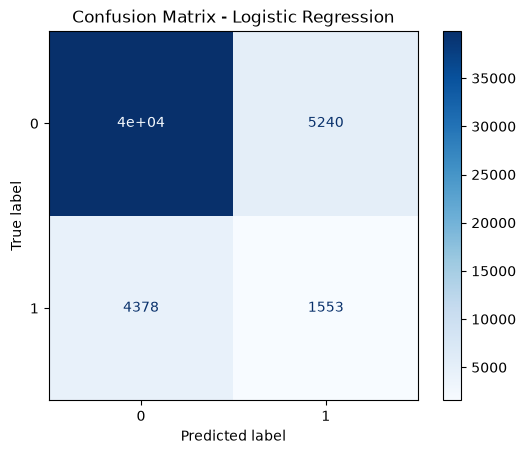

In [9]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89     45139
           1       0.23      0.26      0.24      5931

    accuracy                           0.81     51070
   macro avg       0.56      0.57      0.57     51070
weighted avg       0.82      0.81      0.82     51070



In [11]:
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.6682


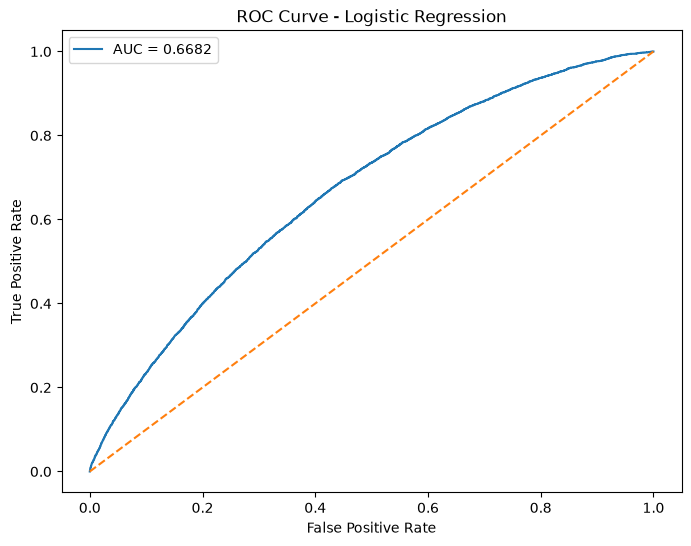

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [13]:
coefficients = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": log_reg.coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute_Coefficient
21,LoanPurpose_Home,-0.674318,0.674318
0,Age,-0.631236,0.631236
11,Education_PhD,-0.610219,0.610219
22,LoanPurpose_Other,-0.603657,0.603657
20,LoanPurpose_Education,-0.599181,0.599181
10,Education_Master's,-0.586062,0.586062
19,LoanPurpose_Business,-0.569974,0.569974
15,MaritalStatus_Married,-0.536873,0.536873
9,Education_High School,-0.500041,0.500041
13,EmploymentType_Self-employed,-0.499558,0.499558


In [14]:
coefficients.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient,Absolute_Coefficient
6,InterestRate,0.484021,0.484021
2,LoanAmount,0.291726,0.291726
8,DTIRatio,0.072215,0.072215
7,LoanTerm,-0.007639,0.007639
5,NumCreditLines,-0.074513,0.074513
3,CreditScore,-0.135207,0.135207
1,Income,-0.328085,0.328085
4,MonthsEmployed,-0.358605,0.358605
17,HasMortgage_Yes,-0.363929,0.363929
18,HasDependents_Yes,-0.403834,0.403834


In [15]:
coefficients.sort_values(
    by="Coefficient"
).head(10)

,Feature,Coefficient,Absolute_Coefficient
21,LoanPurpose_Home,-0.674318,0.674318
0,Age,-0.631236,0.631236
11,Education_PhD,-0.610219,0.610219
22,LoanPurpose_Other,-0.603657,0.603657
20,LoanPurpose_Education,-0.599181,0.599181
10,Education_Master's,-0.586062,0.586062
19,LoanPurpose_Business,-0.569974,0.569974
15,MaritalStatus_Married,-0.536873,0.536873
9,Education_High School,-0.500041,0.500041
13,EmploymentType_Self-employed,-0.499558,0.499558


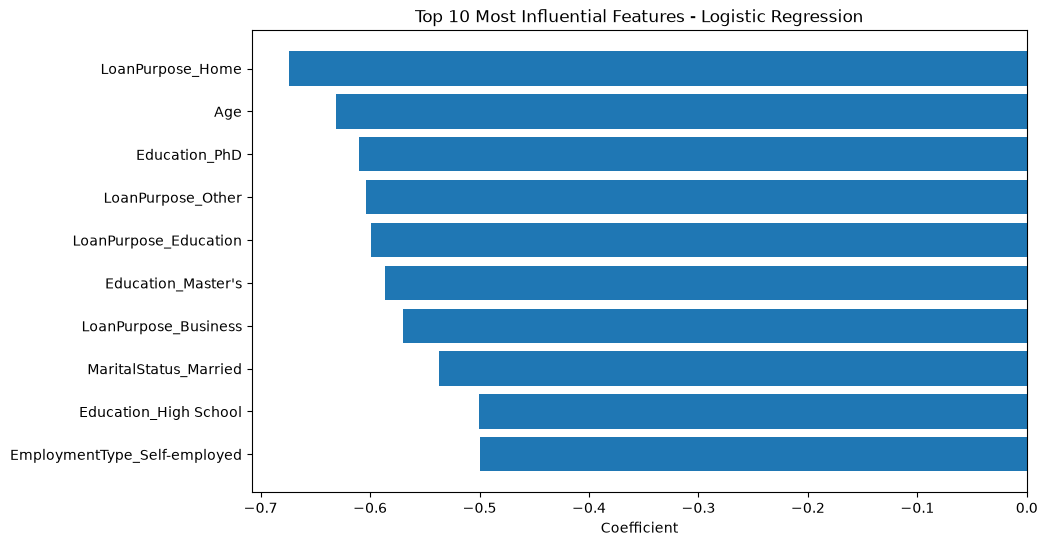

In [16]:
top10 = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Top 10 Most Influential Features - Logistic Regression")
plt.gca().invert_yaxis()
plt.show()

In [17]:
lr_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC-AUC": [roc_auc]
})

lr_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.81167,0.228618,0.261845,0.244106,0.668199


In [18]:
import os

os.makedirs("../results", exist_ok=True)

lr_results.to_csv("../results/lr_results.csv", index=False)

In [21]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(log_reg, "../models/logistic_regression_model.pkl")

print("Logistic Regression model saved successfully!")

Logistic Regression model saved successfully!


In [22]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ("scaler", scaler),
    ("model", log_reg)
])

joblib.dump(pipeline, "../models/loan_default_pipeline.pkl")

print("Pipeline saved successfully!")

NameError: name 'scaler' is not defined